# Data Investigation

Quick EDA for train.csv with a focus on policy-level aggregation (contract_number) and claim behavior.

Notes:
- Premium and claims are duplicated per driver within a policy. For portfolio metrics, aggregate at policy level.
- We will inspect both row-level (driver) and policy-level views.


In [36]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

train_path = "dataset/train.csv"
df = pd.read_csv(train_path)

print("rows:", len(df))
print("columns:", df.shape[1])
df.head(3)

/tmp/ipykernel_2130681/2402247898.py:8: DtypeWarning: Columns (0: bonus_malus, 1: car_year) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(train_path)


rows: 569508
columns: 159


,unique_id,contract_number,premium,premium_wo_term,operation_date,claim_amount,claim_cnt,is_claim,insurer_iin,driver_iin,is_individual_person,is_individual_person_name,is_residence,is_residence_name,region_id,region_name,bonus_malus,age_experience_id,age_experience_name,experience_year,vehicle_type_id,vehicle_type_name,car_age,ownerkato,ownerkato_short,model,mark,car_number,car_year,engine_volume,engine_power,SCORE_1_1,SCORE_1_2,SCORE_1_3,SCORE_1_4,SCORE_1_5,SCORE_1_6,SCORE_1_7,SCORE_1_8,SCORE_1_9,SCORE_1_10,SCORE_2_1,SCORE_2_2,SCORE_2_3,SCORE_3_1,SCORE_3_2,SCORE_3_3,SCORE_3_4,SCORE_3_5,SCORE_3_6,SCORE_3_7,SCORE_3_8,SCORE_3_9,SCORE_3_10,SCORE_4_1,SCORE_4_2,SCORE_4_3,SCORE_4_4,SCORE_4_5,SCORE_4_6,SCORE_4_7,SCORE_4_8,SCORE_4_9,SCORE_4_10,SCORE_4_11,SCORE_4_12,SCORE_4_13,SCORE_4_14,SCORE_4_15,SCORE_4_16,SCORE_4_17,SCORE_4_18,SCORE_4_19,SCORE_4_20,SCORE_4_21,SCORE_4_22,SCORE_4_23,SCORE_4_24,SCORE_4_25,SCORE_4_26,SCORE_4_27,SCORE_4_28,SCORE_4_29,SCORE_4_30,SCORE_5_1,SCORE_5_2,SCORE_5_3,SCORE_5_4,SCORE_5_5,SCORE_5_6,SCORE_5_7,SCORE_5_8,SCORE_5_9,SCORE_5_10,SCORE_5_11,SCORE_5_12,SCORE_6_1,SCORE_6_2,SCORE_6_3,SCORE_7_1,SCORE_7_2,SCORE_7_3,SCORE_8_1,SCORE_8_2,SCORE_8_3,SCORE_9_1,SCORE_9_2,SCORE_9_3,SCORE_9_4,SCORE_9_5,SCORE_9_6,SCORE_9_7,SCORE_9_8,SCORE_9_9,SCORE_9_10,SCORE_9_11,SCORE_9_12,SCORE_9_13,SCORE_9_14,SCORE_9_15,SCORE_9_16,SCORE_9_17,SCORE_9_18,SCORE_9_19,SCORE_9_20,SCORE_9_21,SCORE_9_22,SCORE_9_23,SCORE_9_24,SCORE_10_1,SCORE_10_2,SCORE_10_3,SCORE_10_4,SCORE_10_5,SCORE_10_6,SCORE_11_1,SCORE_11_2,SCORE_11_3,SCORE_11_4,SCORE_11_5,SCORE_11_6,SCORE_11_7,SCORE_11_8,SCORE_11_9,SCORE_11_10,SCORE_11_11,SCORE_11_12,SCORE_11_13,SCORE_11_14,SCORE_12_1,SCORE_12_2,SCORE_12_3,SCORE_12_4,SCORE_12_5,SCORE_12_6,SCORE_12_9_1,SCORE_12_8,SCORE_12_7,SCORE_12_10
0,C97AFBBF-D191-42BB-8429-71F99D7F4B65,30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b...,11691.0,11691.0,2022-01-03,NaN,NaN,0,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,1,Физ. лицо,1,Резидент,1,01 Алматинская область,13,5,старше 25 лет/стаж вождения более 2 лет,10,1,Легковые,до 7 лет включ.,1.952201e+09,1952.0,SONATA,HYUNDAI,61a50ba901fe1e632512ae9796d87856f255ef0f243b3e...,2020,2497.0,132.0,7.0,5.0,4.0,1.0,2.0,3.0,7.0,5.0,9.0,43.0,4.0,4.0,12.0,6.0,7.0,11.0,1.0,8.0,11.0,11.0,2.0,2.0,10.0,10.0,11.0,10.0,8.0,1.0,10.0,8.0,1.0,1.0,4.0,6.0,7.0,11.0,6.0,7.0,5.0,11.0,10.0,10.0,4.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,11.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,8.0,10.0,10.0,4.0,10.0,10.0,8.0,6.0,1.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,6.0,5.0,9.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
1,CBF0BF9E-B247-41EE-A59C-79D56F619034,6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59...,14121.0,14121.0,2022-01-03,NaN,NaN,0,ccbc33ecce804b79c57fd692d9974fba302b27a15bfd27...,6c4851642b845a87e17f96c16bdd99e13da640e783c2f6...,1,Физ. лицо,1,Резидент,20,18 Туркестанская область,13,5,старше 25 лет/стаж вождения более 2 лет,0,1,Легковые,свыше 7 лет,6.116100e+09,6116.0,21703 138 31,LADA,47b6f0d2d4f70ffa0a154e9500ac2b80af5aae48b3c2aa...,2013,1596.0,59.0,9.0,9.0,9.0,2.0,3.0,5.0,10.0,10.0,10.0,67.0,2.0,9.0,25.0,10.0,1.0,11.0,1.0,6.0,10.0,10.0,10.0,10.0,10.0,5.0,7.0,4.0,3.0,1.0,5.0,3.0,1.0,1.0,1.0,1.0,5.0,10.0,4.0,3.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,7.0,8.0,7.0,7.0,6.0,8.0,7.0,8.0,7.0,7.0,6.0,1.0,4.0,6.0,NaN,NaN,NaN,1.0,1.0,1.0,6.0,6.0,5.0,5.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,5.0,5.0,6.0,6.0,6.0,6.0,7.0,6.0,6.0,6.0,1.0,1.0,1.0,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,9470871E-8BA6-4FAD-B4F9-9457229652E9,369c23be5e6c413661e872e20bc682df54ccc7f2eb0193...,7371.0,4483.0,2022-01-03,NaN,NaN,0,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,1,Физ. л

In [37]:
# Basic schema overview
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "n_missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("n_missing", ascending=False)

schema.head(15)

,dtype,n_unique,n_missing,missing_pct
SCORE_12_4,float64,1,569246,99.95
SCORE_12_6,float64,1,569155,99.94
SCORE_12_5,float64,1,568355,99.80
SCORE_12_1,float64,1,567738,99.69
SCORE_12_2,float64,1,567552,99.66
SCORE_12_3,float64,1,565842,99.36
claim_cnt,float64,6,558414,98.05
claim_amount,float64,3414,558414,98.05
SCORE_12_9_1,float64,1,547110,96.07
SCORE_11_9,float64,2,486576,85.44


In [38]:
# Target distribution at row level
from IPython.display import display

if "is_claim" in df.columns:
    row_level = df["is_claim"].value_counts(dropna=False).to_frame("count")
    row_level["pct"] = (row_level["count"] / len(df) * 100).round(3)
    display(row_level)
else:
    print("is_claim not found")


,count,pct
is_claim,,
0,558414,98.052
1,11094,1.948


In [39]:
# Policy-level aggregation (contract_number)
policy_key = "contract_number"

policy_cols = [
    "premium",
    "premium_wo_term",
    "claim_amount",
    "claim_cnt",
    "is_claim",
]

missing_policy_cols = [c for c in policy_cols + [policy_key] if c not in df.columns]
if missing_policy_cols:
    print("Missing columns:", missing_policy_cols)
else:
    # Metrics should be counted once per policy, so we take first value in each policy group
    policy = (
        df.groupby(policy_key, as_index=False)[policy_cols]
        .first()
    )
    display(policy.head(3))

,contract_number,premium,premium_wo_term,claim_amount,claim_cnt,is_claim
0,000153ebe13e6fff0f59b2977d403c82ca2a97f3133d96...,16195.0,16195.0,NaN,NaN,0
1,0001a1cb0431d08f3ccb0a5ec65349678dad2266de183d...,14289.0,14289.0,NaN,NaN,0
2,0001e313d188345c3faa257552bd4287469bf7268229e0...,7249.0,7249.0,NaN,NaN,0


In [40]:
# Portfolio loss ratio at policy level
if "policy" in locals():
    premium_sum = policy["premium_wo_term"].sum()
    claim_sum = policy["claim_amount"].sum()
    loss_ratio = (claim_sum / premium_sum) if premium_sum else np.nan

    print("Policies:", len(policy))
    print("Premium (wo term):", premium_sum)
    print("Claims total:", claim_sum)
    print("Loss ratio:", round(loss_ratio * 100, 2), "%")

Policies: 180635
Premium (wo term): 1922863290.0
Claims total: 2371706450.08
Loss ratio: 123.34 %


In [41]:
# Drivers per policy distribution
if policy_key in df.columns:
    drivers_per_policy = df.groupby(policy_key).size()
    drivers_per_policy.describe()
    display(drivers_per_policy.describe())


count    180635.000000
mean          3.152811
std           1.325061
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          32.000000
dtype: float64

## Расширенный EDA

Ниже — расширенный анализ данных с учетом бизнес-контекста из постановки задачи и дублирования показателей на уровне полиса. Метрики убыточности считаются на уровне `contract_number`, а визуализации смотрим и в разрезе водителей, и в разрезе полисов.

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Re-read data with safer parsing
train_path = "dataset/train.csv"

df = pd.read_csv(train_path, low_memory=False)

# Parse dates
if "operation_date" in df.columns:
    df["operation_date"] = pd.to_datetime(df["operation_date"], errors="coerce")

# Coerce known numeric columns that might have mixed types
numeric_candidates = [
    "bonus_malus",
    "car_year",
    "engine_volume",
    "engine_power",
    "premium",
    "premium_wo_term",
    "claim_amount",
    "claim_cnt",
    "experience_year",
    "car_age",
]

numeric_candidates += [c for c in df.columns if c.startswith("SCORE_")]

coerced_cols = []
for col in numeric_candidates:
    if col in df.columns and df[col].dtype == "object":
        df[col] = pd.to_numeric(df[col], errors="coerce")
        coerced_cols.append(col)

print("coerced numeric columns:", len(coerced_cols))


try:
    schema_desc = pd.read_csv("dataset_description.csv")
    display(schema_desc.head(10))
except FileNotFoundError:
    print("dataset_description.csv not found")

coerced numeric columns: 0


,столбец,Описание
0,unique_id,Уникальный идентификатор строки
1,contract_number,Номер страхового полиса
2,premium,Премия
3,premium_wo_term,Премия за вычетом расторжения
4,operation_date,Дата оформления страхового полиса
5,claim_amount,Итоговая сумма выплат
6,claim_cnt,Количество произведенных выплат
7,is_claim,Факт выплаты
8,insurer_iin,ИИН страхователя на чье имя оформлен полис
9,driver_iin,ИИН водителя ТС


In [43]:
# Data quality report
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "n_missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("n_missing", ascending=False)

# Suspected ID / high-cardinality columns
high_card = schema[schema["n_unique"] > 0.9 * len(df)].head(10)

# Duplicates
row_dups = df.duplicated().sum()
policy_key = "contract_number"
policy_dups = df.duplicated(subset=[policy_key]).sum() if policy_key in df.columns else None

print("row-level duplicates:", row_dups)
print("policy-level duplicate rows:", policy_dups)

schema.head(20)

row-level duplicates: 0
policy-level duplicate rows: 388873


,dtype,n_unique,n_missing,missing_pct
SCORE_12_4,float64,1,569246,99.95
SCORE_12_6,float64,1,569155,99.94
SCORE_12_5,float64,1,568355,99.80
SCORE_12_1,float64,1,567738,99.69
SCORE_12_2,float64,1,567552,99.66
SCORE_12_3,float64,1,565842,99.36
claim_cnt,float64,6,558414,98.05
claim_amount,float64,3414,558414,98.05
SCORE_12_9_1,float64,1,547110,96.07
SCORE_11_9,float64,2,486576,85.44


In [44]:
# High-cardinality and top categories
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in ["region_name", "vehicle_type_name", "mark", "model"]:
    if col in cat_cols:
        print("\nTop categories for", col)
        display(df[col].value_counts(dropna=False).head(10))

print("\nHigh-cardinality columns (top 10 by n_unique):")
display(schema.loc[cat_cols].sort_values("n_unique", ascending=False).head(10))


Top categories for region_name


/tmp/ipykernel_2130681/305302102.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


region_name
01 Алматинская область       111212
15 Алматы                     78115
18 Туркестанская область      74973
17 Шымкент                    68659
16 Астана                     53296
05 Карагандинская область     37790
09 Жамбылская область         34503
12 Кызылординская область     18794
10 Актюбинская область        17752
14 Мангистауская область      16296
Name: count, dtype: int64


Top categories for vehicle_type_name


vehicle_type_name
Легковые                548061
Грузовые                 10478
Прицепы(полуприцепы)      7660
Автобусы до 16 п.м.       1573
Автобусы > 16 п.м.        1019
Мототранспорт              717
Name: count, dtype: int64

...

mark
TOYOTA           111667
HYUNDAI           44013
VOLKSWAGEN        34217
MERCEDES-BENZ     28451
LADA              26721
KIA               24732
CHEVROLET         23147
NISSAN            22903
ВАЗ               22509
AUDI              21931
Name: count, dtype: int64


Top categories for model


model
CAMRY      45202
NEXIA      13309
ACCENT     12572
PASSAT     11476
COBALT     10099
RIO         8703
COROLLA     7831
100         7198
GOLF        6957
VECTRA      6870
Name: count, dtype: int64


High-cardinality columns (top 10 by n_unique):


,dtype,n_unique,n_missing,missing_pct
unique_id,str,569508,0,0.00
driver_iin,str,347147,1055,0.19
contract_number,str,180635,0,0.00
car_number,str,164600,0,0.00
insurer_iin,str,126799,354,0.06
model,str,11184,88,0.02
mark,str,1524,679,0.12
car_year,str,111,0,0.00
region_name,str,22,0,0.00
bonus_malus,str,15,8,0.00


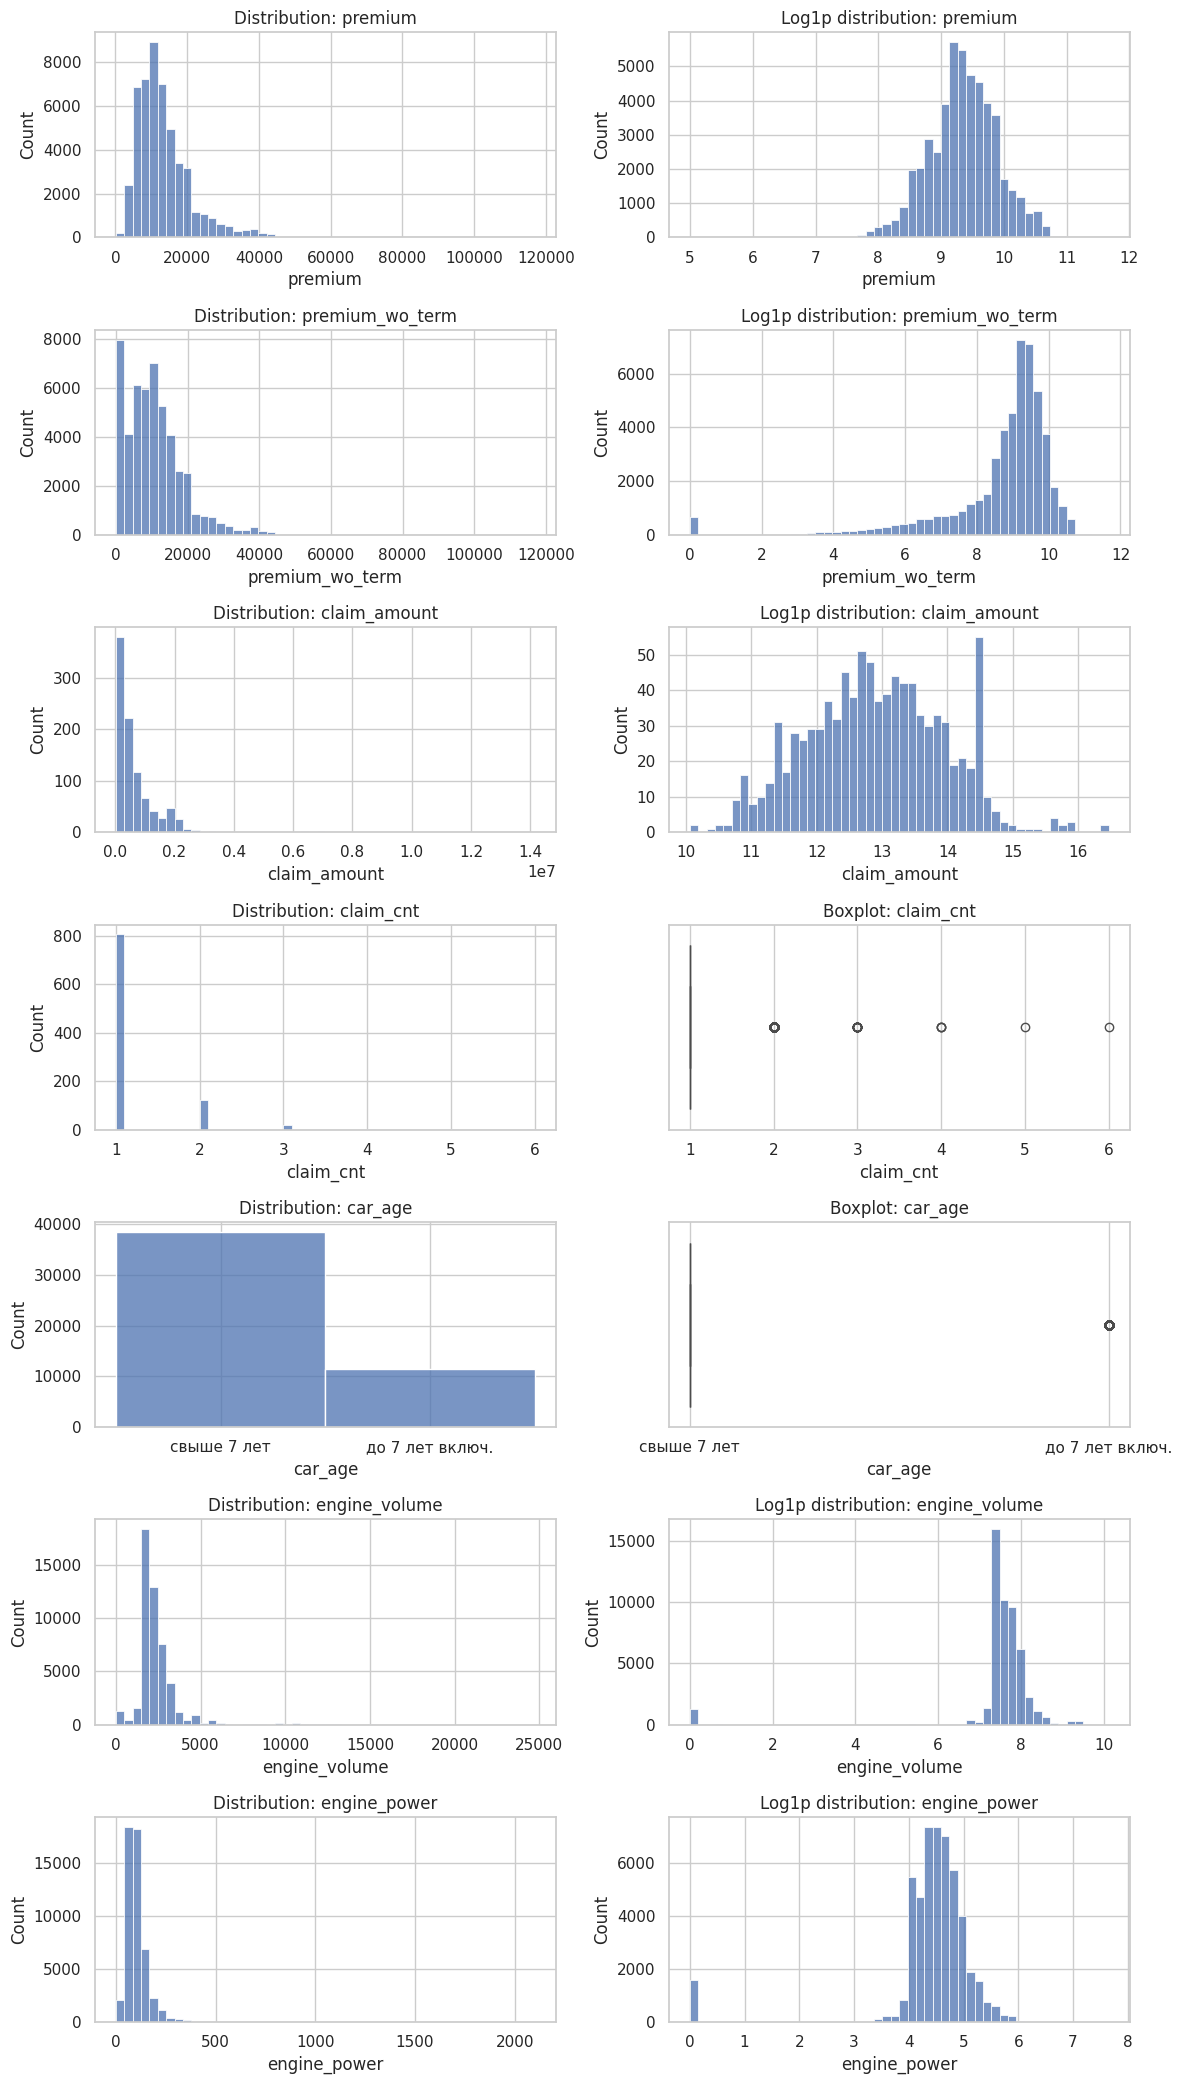

In [45]:
# Numeric distributions (sample for plotting)
plot_cols = [
    "premium",
    "premium_wo_term",
    "claim_amount",
    "claim_cnt",
    "car_age",
    "engine_volume",
    "engine_power",
]

plot_cols = [c for c in plot_cols if c in df.columns]

sample = df[plot_cols].sample(n=min(50000, len(df)), random_state=42)

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 3 * len(plot_cols)))

if len(plot_cols) == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    sns.histplot(sample[col], ax=axes[i][0], bins=50, kde=False)
    axes[i][0].set_title(f"Distribution: {col}")

    # Log scale helps for heavy-tailed columns like claim_amount
    if col in ["claim_amount", "premium", "premium_wo_term", "engine_volume", "engine_power"]:
        sns.histplot(np.log1p(sample[col]), ax=axes[i][1], bins=50, kde=False)
        axes[i][1].set_title(f"Log1p distribution: {col}")
    else:
        sns.boxplot(x=sample[col], ax=axes[i][1])
        axes[i][1].set_title(f"Boxplot: {col}")

plt.tight_layout()

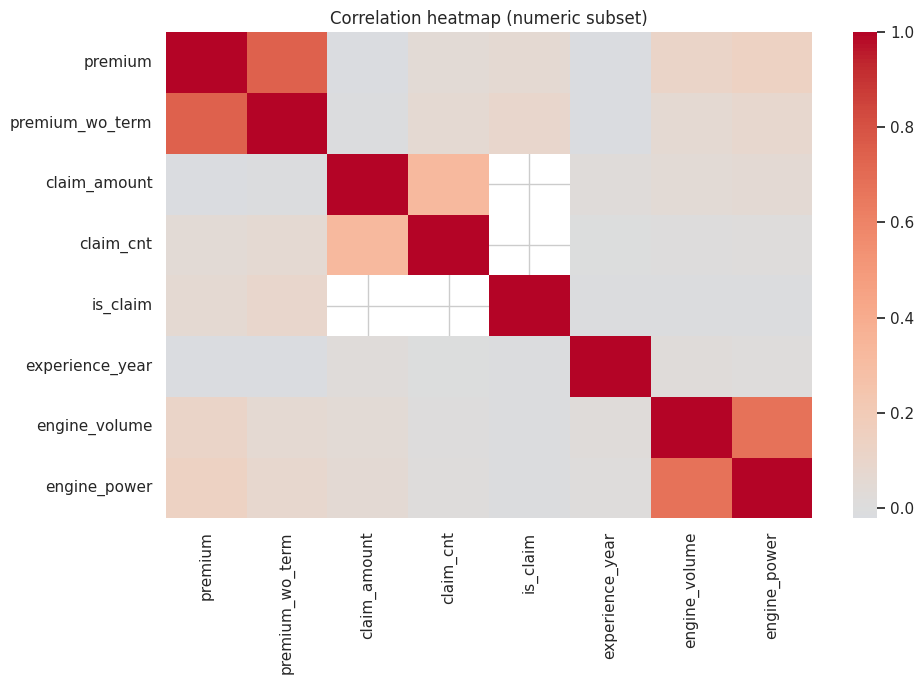

In [46]:
# Correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

corr_cols = [
    "premium",
    "premium_wo_term",
    "claim_amount",
    "claim_cnt",
    "is_claim",
    "bonus_malus",
    "experience_year",
    "car_age",
    "engine_volume",
    "engine_power",
]

corr_cols = [c for c in corr_cols if c in numeric_cols]

corr_sample = df[corr_cols].sample(n=min(50000, len(df)), random_state=42)

corr = corr_sample.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric subset)")
plt.tight_layout()

## Анализ выплат (claim) и убыточности

Ниже — распределение целевой переменной, базовые статистики выплат и сегментный анализ на уровне полиса.

In [47]:
# Target distribution (row-level)
if "is_claim" in df.columns:
    target = df["is_claim"].value_counts(dropna=False).to_frame("count")
    target["pct"] = (target["count"] / len(df) * 100).round(3)
    display(target)

# Claim stats by claim flag
if "is_claim" in df.columns and "claim_amount" in df.columns:
    claim_stats = df.groupby("is_claim")["claim_amount"].agg(["count", "mean", "median", "max"]).round(2)
    display(claim_stats)

# Policy-level table with deduplicated policy metrics
policy_key = "contract_number"
policy_cols = ["premium", "premium_wo_term", "claim_amount", "claim_cnt", "is_claim"]

missing_policy_cols = [c for c in policy_cols + [policy_key] if c not in df.columns]
if not missing_policy_cols:
    policy = df.groupby(policy_key, as_index=False)[policy_cols].first()

    # Loss ratio (portfolio)
    premium_sum = policy["premium_wo_term"].sum()
    claim_sum = policy["claim_amount"].sum()
    loss_ratio = (claim_sum / premium_sum) if premium_sum else np.nan

    print("Policies:", len(policy))
    print("Loss ratio (policy-level):", round(loss_ratio * 100, 2), "%")

    # Merge policy-level metrics with representative policy features
    policy_info = df.groupby(policy_key, as_index=False).first()

    def segment_loss_ratio(group_col, min_policies=200):
        if group_col not in policy_info.columns:
            return None
        merged = policy_info[[policy_key, group_col]].merge(policy, on=policy_key, how="left")
        agg = (
            merged.groupby(group_col)
            .agg(
                policies=(policy_key, "nunique"),
                premium_wo_term=("premium_wo_term", "sum"),
                claim_amount=("claim_amount", "sum"),
                claim_cnt=("claim_cnt", "sum"),
                claim_rate=("is_claim", "mean"),
            )
            .reset_index()
        )
        agg["loss_ratio"] = agg["claim_amount"] / agg["premium_wo_term"]
        agg = agg[agg["policies"] >= min_policies]
        return agg.sort_values("loss_ratio", ascending=False)

    for group_col in ["region_name", "vehicle_type_name", "bonus_malus", "age_experience_name"]:
        seg = segment_loss_ratio(group_col)
        if seg is not None and not seg.empty:
            print("\nLoss ratio by", group_col)
            display(seg.head(10))
else:
    print("Missing columns:", missing_policy_cols)

,count,pct
is_claim,,
0,558414,98.052
1,11094,1.948


,count,mean,median,max
is_claim,,,,
0,0,NaN,NaN,NaN
1,11094,668735.83,382871.0,23284342.0


Policies: 180635
Loss ratio (policy-level): 123.34 %


/tmp/ipykernel_2130681/3914957146.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  policy_info = df.groupby(policy_key, as_index=False).first()



Loss ratio by region_name


...

,vehicle_type_name,policies,premium_wo_term,claim_amount,claim_cnt,claim_rate,loss_ratio
0,Автобусы > 16 п.м.,291,3.158921e+06,2.328434e+07,6.0,0.003436,7.370980
3,Легковые,174445,1.861375e+09,2.308687e+09,4158.0,0.020184,1.240313
2,Грузовые,3086,4.063792e+07,3.468902e+07,54.0,0.014258,0.853612
5,Прицепы(полуприцепы),2109,1.122303e+07,4.770277e+06,11.0,0.003319,0.425044
1,Автобусы до 16 п.м.,468,4.835669e+06,2.754410e+05,2.0,0.004274,0.056960
4,Мототранспорт,236,1.632521e+06,0.000000e+00,0.0,0.000000,0.000000



Loss ratio by bonus_malus


,bonus_malus,policies,premium_wo_term,claim_amount,claim_cnt,claim_rate,loss_ratio
7,3,10127,142896381.0,2.537018e+08,429.0,0.035252,1.775425
2,10,7411,78179809.0,1.339345e+08,203.0,0.023883,1.713160
8,4,9748,130647033.0,1.920355e+08,295.0,0.026467,1.469880
1,1,261,5380604.0,7.737885e+06,15.0,0.049808,1.438107
10,6,6546,76447316.0,1.054608e+08,202.0,0.026581,1.379523
9,5,7628,94247935.0,1.290272e+08,232.0,0.025433,1.369019
3,11,8691,87741991.0,1.191991e+08,178.0,0.018065,1.358519
11,7,8355,98991102.0,1.301896e+08,258.0,0.026332,1.315164
13,9,7824,85763140.0,1.123264e+08,199.0,0.021345,1.309729
6,2,437,7937958.0,9.102619e+06,23.0,0.041190,1.146720



Loss ratio by age_experience_name


,age_experience_name,policies,premium_wo_term,claim_amount,claim_cnt,claim_rate,loss_ratio
3,старше 25 лет/стаж вождения менее 2 лет,5235,7.092779e+07,1.192078e+08,180.0,0.029035,1.680693
1,менее 25 лет/стаж вождения менее 2 лет,11058,1.484540e+08,2.390302e+08,399.0,0.030295,1.610129
0,менее 25 лет/стаж вождения более 2 лет,12894,1.500333e+08,2.097081e+08,359.0,0.023267,1.397743
2,старше 25 лет/стаж вождения более 2 лет,151448,1.553448e+09,1.803760e+09,3293.0,0.018409,1.161133


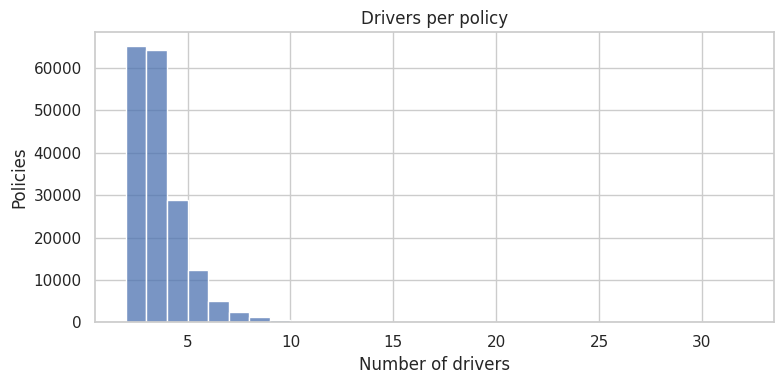

In [48]:
# Drivers per policy distribution (plot)
if policy_key in df.columns:
    drivers_per_policy = df.groupby(policy_key).size()

    plt.figure(figsize=(8, 4))
    sns.histplot(drivers_per_policy, bins=30)
    plt.title("Drivers per policy")
    plt.xlabel("Number of drivers")
    plt.ylabel("Policies")
    plt.tight_layout()

## Ключевые наблюдения (черновик)

- Дисбаланс по `is_claim` требует аккуратной работы с метриками и, вероятно, частотно-тяжестным подходом.
- На уровне полиса показатели премии и выплат нужно учитывать один раз (дублирование по водителям).
- Ряд числовых признаков имеет сильную асимметрию; лог-преобразования полезны для визуализации и моделей.
- Есть высококардинальные признаки (например, `car_number`, `contract_number`), которые требуют осторожности при моделировании.
- Сегменты с высокой убыточностью заслуживают отдельного анализа (регион, тип ТС, бонус-малус).

> При необходимости расширим раздел с детальными сегментными выводами после просмотра результатов ячеек.

## Дополнительный анализ

Ниже — временная динамика, частота/тяжесть убытков на уровне полиса и бининговый анализ по ключевым числовым признакам.

/tmp/ipykernel_2130681/710833560.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  policy_info = df.groupby(policy_key, as_index=False).first()


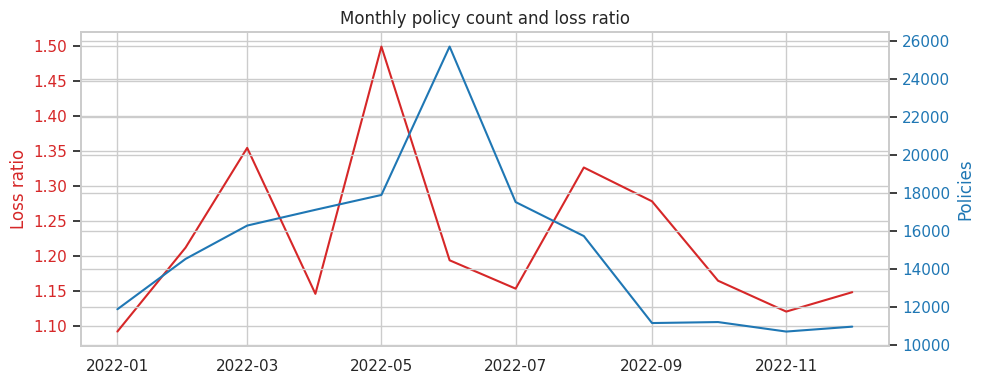

In [49]:
# Time dynamics at policy level
if "operation_date" in df.columns and policy_key in df.columns:
    policy_info = df.groupby(policy_key, as_index=False).first()

    policy_time = policy_info[[policy_key, "operation_date"]].merge(
        policy[[policy_key, "premium_wo_term", "claim_amount", "is_claim"]],
        on=policy_key,
        how="left",
    )

    policy_time["month"] = policy_time["operation_date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        policy_time.groupby("month")
        .agg(
            policies=(policy_key, "nunique"),
            premium_wo_term=("premium_wo_term", "sum"),
            claim_amount=("claim_amount", "sum"),
            claim_rate=("is_claim", "mean"),
        )
        .reset_index()
    )
    monthly["loss_ratio"] = monthly["claim_amount"] / monthly["premium_wo_term"]

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(monthly["month"], monthly["loss_ratio"], color="tab:red", label="Loss ratio")
    ax1.set_ylabel("Loss ratio", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    ax2.plot(monthly["month"], monthly["policies"], color="tab:blue", label="Policies")
    ax2.set_ylabel("Policies", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title("Monthly policy count and loss ratio")
    plt.tight_layout()
else:
    print("operation_date or policy_key not found")

Policy claim frequency: 1.979 %
Mean severity (claim_amount | claim): 663414.39


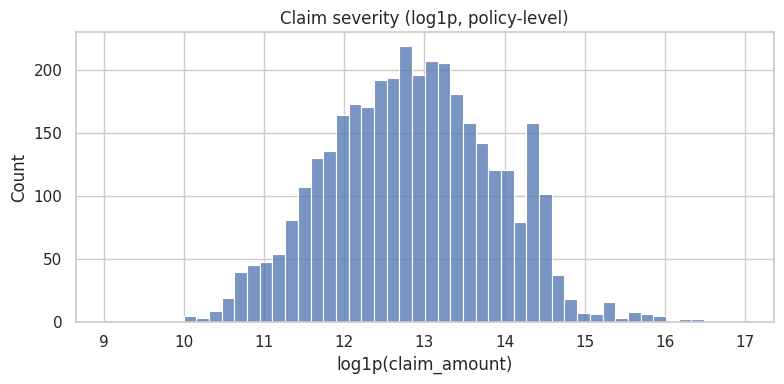

In [50]:
# Frequency and severity at policy level
if "policy" in locals():
    policy_level = policy.copy()
    policy_level["has_claim"] = policy_level["claim_amount"].fillna(0) > 0

    freq = policy_level["has_claim"].mean()
    sev = policy_level.loc[policy_level["has_claim"], "claim_amount"].mean()

    print("Policy claim frequency:", round(freq * 100, 3), "%")
    print("Mean severity (claim_amount | claim):", round(sev, 2))

    plt.figure(figsize=(8, 4))
    sns.histplot(
        np.log1p(policy_level.loc[policy_level["has_claim"], "claim_amount"]),
        bins=50,
    )
    plt.title("Claim severity (log1p, policy-level)")
    plt.xlabel("log1p(claim_amount)")
    plt.tight_layout()
else:
    print("policy table not found")

In [51]:
# Binning analysis for key numeric features (policy-level)
if "policy" in locals() and "policy_info" in locals():
    merged = policy_info[[policy_key, "bonus_malus", "experience_year", "car_age", "engine_power", "engine_volume"]].merge(
        policy,
        on=policy_key,
        how="left",
    )

    def bin_report(col, bins=10):
        if col not in merged.columns:
            return None
        series = merged[col]
        if series.dropna().nunique() < 3:
            return None
        binned = pd.qcut(series, q=min(bins, series.dropna().nunique()), duplicates="drop")
        out = (
            merged.assign(bin=binned)
            .groupby("bin")
            .agg(
                policies=(policy_key, "nunique"),
                premium_wo_term=("premium_wo_term", "sum"),
                claim_amount=("claim_amount", "sum"),
                claim_rate=("is_claim", "mean"),
            )
            .reset_index()
        )
        out["loss_ratio"] = out["claim_amount"] / out["premium_wo_term"]
        return out

    for col in ["bonus_malus", "experience_year", "car_age", "engine_power", "engine_volume"]:
        rep = bin_report(col)
        if rep is not None:
            print("\nBinned report for", col)
            display(rep.head(10))
else:
    print("policy or policy_info not found")

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [52]:
# Missingness and signal for SCORE_* features
score_cols = [c for c in df.columns if c.startswith("SCORE_")]

if score_cols:
    score_missing = (
        df[score_cols].isna().mean().sort_values(ascending=False).to_frame("missing_pct")
    )
    score_missing["missing_pct"] = (score_missing["missing_pct"] * 100).round(2)

    print("Top SCORE_* columns by missingness")
    display(score_missing.head(10))

    if "is_claim" in df.columns:
        # Quick decile check on a subset of SCORE features
        sample_scores = score_cols[:6]
        for col in sample_scores:
            if df[col].dropna().nunique() > 5:
                deciles = pd.qcut(df[col], q=10, duplicates="drop")
                out = df.groupby(deciles)["is_claim"].mean().reset_index()
                print("\nClaim rate by deciles for", col)
                display(out)
else:
    print("No SCORE_* columns found")

Top SCORE_* columns by missingness


,missing_pct
SCORE_12_4,99.95
SCORE_12_6,99.94
SCORE_12_5,99.80
SCORE_12_1,99.69
SCORE_12_2,99.66
SCORE_12_3,99.36
SCORE_12_9_1,96.07
SCORE_11_9,85.44
SCORE_11_1,85.44
SCORE_11_7,85.44



Claim rate by deciles for SCORE_1_1


,SCORE_1_1,is_claim
0,"(0.999, 2.0]",0.018967
1,"(2.0, 3.0]",0.019453
2,"(3.0, 5.0]",0.019392
3,"(5.0, 7.0]",0.020593
4,"(7.0, 8.0]",0.021066
5,"(8.0, 9.0]",0.021288
6,"(9.0, 10.0]",0.018773



Claim rate by deciles for SCORE_1_2


,SCORE_1_2,is_claim
0,"(0.999, 2.0]",0.018983
1,"(2.0, 3.0]",0.018838
2,"(3.0, 5.0]",0.019551
3,"(5.0, 7.0]",0.020919
4,"(7.0, 8.0]",0.021698
5,"(8.0, 9.0]",0.020568
6,"(9.0, 10.0]",0.018785



Claim rate by deciles for SCORE_1_3


,SCORE_1_3,is_claim
0,"(0.999, 2.0]",0.018622
1,"(2.0, 3.0]",0.019283
2,"(3.0, 5.0]",0.020492
3,"(5.0, 6.0]",0.020552
4,"(6.0, 8.0]",0.020713
5,"(8.0, 9.0]",0.021274
6,"(9.0, 10.0]",0.018610



Claim rate by deciles for SCORE_1_6


,SCORE_1_6,is_claim
0,"(0.999, 2.0]",0.019782
1,"(2.0, 3.0]",0.020405
2,"(3.0, 4.0]",0.018978
3,"(4.0, 6.0]",0.020159
4,"(6.0, 10.0]",0.019961
